# US-007：时频分析与 ERP 可视化

**目标：** 绘制高质量 ERP 波形图、脑地形图和时频图，从多维度呈现分析结果。

## 0. 准备数据

In [33]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

# 目录配置
data_dir = os.path.abspath("./../datasets")
os.makedirs(data_dir, exist_ok=True)
# 每次运行强制更新 config
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)
print("=" * 80)
print("config file =", mne.get_config_path())
print("=" * 80)
# 打印config 内容,友好格式
config = mne.get_config()
for key, value in config.items():
    print(f"* {key:25s}: {value}")

# 加载 sample 数据并做预处理
sample_dir = mne.datasets.sample.data_path()
raw_fname = sample_dir / "MEG" / "sample" / "sample_audvis_raw.fif"
# 提取 EEG 通道和 STI 通道
raw = mne.io.read_raw_fif(raw_fname, preload=True).pick_types(eeg=True, stim=True)
raw.filter(l_freq=1.0, h_freq=40.0)

# 事件和 Epochs
events = mne.find_events(raw, stim_channel='STI 014')
event_id = {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4}

epochs = mne.Epochs(
    raw, events, event_id=event_id,
    tmin=-0.5, tmax=1.0,
    baseline=(None, 0),
    preload=True,
    reject=dict(eeg=150e-6),
    verbose=False,
)
print(f"Epochs: {epochs}")

config file = /Users/usst_ziyi/.mne/mne-python.json
* MNE_BROWSE_RAW_SIZE      : 20.416666666666668,12.819444444444445
* MNE_DATA                 : /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/datasets
* MNE_DATASETS_SAMPLE_PATH : /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/datasets
* MNE_PATH                 : ./datasets
Opening raw data file /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/datasets/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, ze

## 1. Evoked — 蝴蝶图 (Butterfly Plot)

所有通道的 ERP 波形叠加显示，快速了解整体响应。

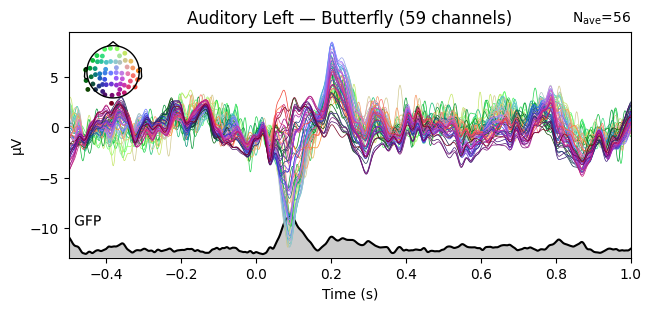

In [34]:
evoked_aud = epochs['auditory/left'].average()

# 蝴蝶图
fig = evoked_aud.plot(
    spatial_colors=True,         # 每条线不同颜色
    titles='Auditory Left — Butterfly',
    gfp=True,
)
# GFP 是所有通道在每一时刻信号的标准差，反映整体脑活动强度，峰值通常指示有意义的事件相关电位成分
# 参数 gfp=True → 叠加绘制 GFP (Global Field Power)

## 2. 脑地形图 (Topomap)

在指定时间点上绘制头皮电位分布。

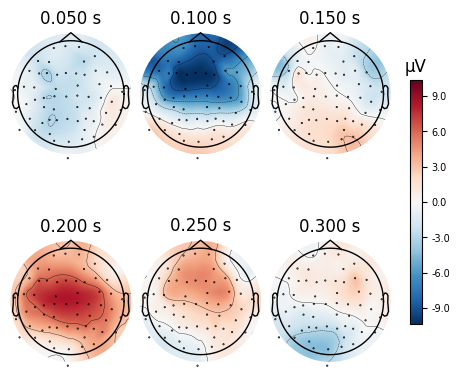

In [35]:
# 绘制特定时间点的地形图序列
times = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]  # 秒
fig = evoked_aud.plot_topomap(
    times=times,
    ch_type='eeg',
    time_unit='s',
    colorbar=True,
    ncols=3, nrows='auto',
)

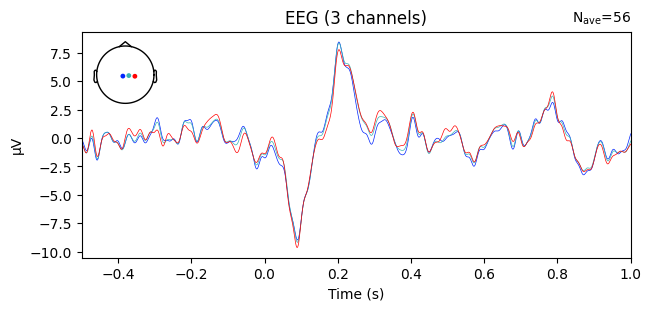

In [25]:
fig = evoked_aud.pick(['EEG 030', 'EEG 031', 'EEG 032']).plot()

### 2.1 选择特定通道画 ERP

Need more than one channel to make topography for eeg. Disabling interactivity.


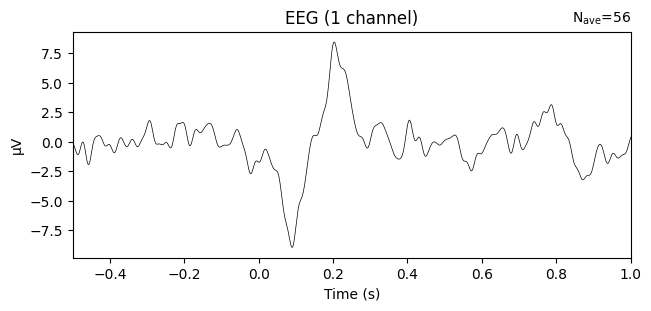

In [26]:
# 画 Cz 通道（中央顶叶，N100/P300 等经典 ERP 成分常看的位置）
# 用 EEG 030 (sample 数据中近似 Cz)
fig = evoked_aud.pick('EEG 030').plot()



## 3. 多条件 ERP 对比

`plot_compare_evokeds` 是同类型的标准对比方式。

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


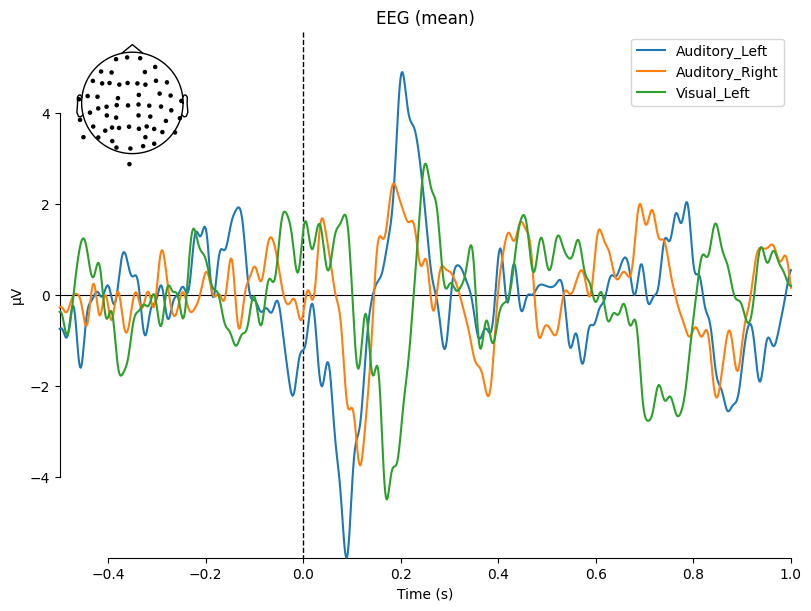

In [48]:
# 合并左右耳听觉条件
evoked_aud_L = epochs['auditory/left'].average() # 试次间平均
evoked_aud_R = epochs['auditory/right'].average() # 试次间平均
evoked_vis_L = epochs['visual/left'].average() # 试次间平均

# 多条件对比
fig = mne.viz.plot_compare_evokeds(
    dict(
        Auditory_Left=evoked_aud_L,
        Auditory_Right=evoked_aud_R,
        Visual_Left=evoked_vis_L,
    ),
    picks='eeg',           # 只画 EEG
    combine='mean',         # 通道间平均
    legend='upper right',
    show_sensors='upper left',
    ci=0.95,               # 95% 置信区间（阴影）
    truncate_yaxis='auto',
)

## 4. Joint Plot — 时域+地形图联动

一张图同时显示指定通道的 ERP 波形 + 关键时间点的地形图。

No projector specified for this dataset. Please consider the method self.add_proj.


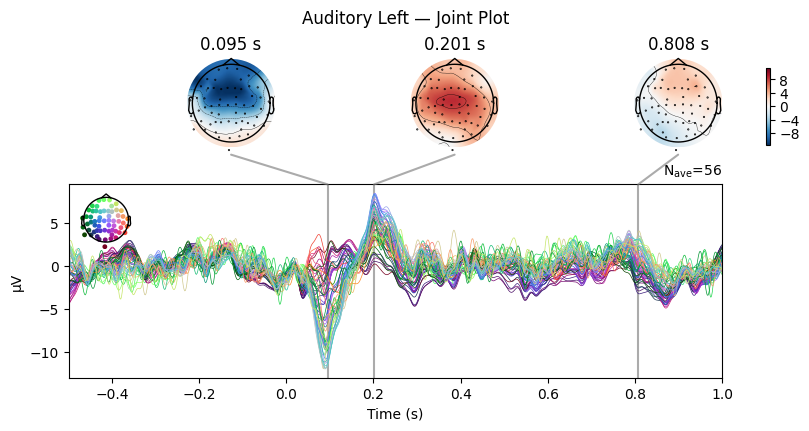

In [49]:
# Joint plot：显示 Cz 的波形 + 峰值时间点的地形图
evoked_aud_joint = epochs['auditory/left'].average()
fig = evoked_aud_joint.plot_joint(
    times='peaks',         # 自动找峰值
    title='Auditory Left — Joint Plot',
)

## 5. 时频分析

用小波变换或 multitaper 计算时频表示 (TFR)。

In [69]:
from mne.time_frequency import tfr_morlet

# 选择频率范围和参数
freqs = np.logspace(*np.log10([4, 30]), num=20)  # 对数间隔 4-30 Hz
print(freqs)

# # 绘制频率点二维图
# from matplotlib import pyplot as plt
# fig,ax = plt.subplots(figsize=(10, 6))
# ax.plot(np.arange(len(freqs)), freqs)


n_cycles = freqs / 2.    # 频率越低小波周期越少

# 计算时频表示
power = epochs['auditory/left'].compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    use_fft=True,
    return_itc=False,        # 只算功率，不算相位一致性
    decim=3,                 # 降采样加速
    n_jobs=1,
)
print(f"TFR 形状: {power.data.shape}")  # (n_epochs, n_channels, n_freqs, n_times)

[ 4.          4.44749888  4.94506157  5.49828895  6.11340848  6.79734434
  7.55779534  8.40332157  9.34344082 10.38873564 11.55097253 12.84323434
 14.28006759 15.87764615 17.65395336 19.62898444 21.82497158 24.26663416
 26.98145705 30.        ]
TFR 形状: (56, 59, 20, 301)


### 5.1 时频图：单通道单条件

Applying baseline correction (mode: logratio)


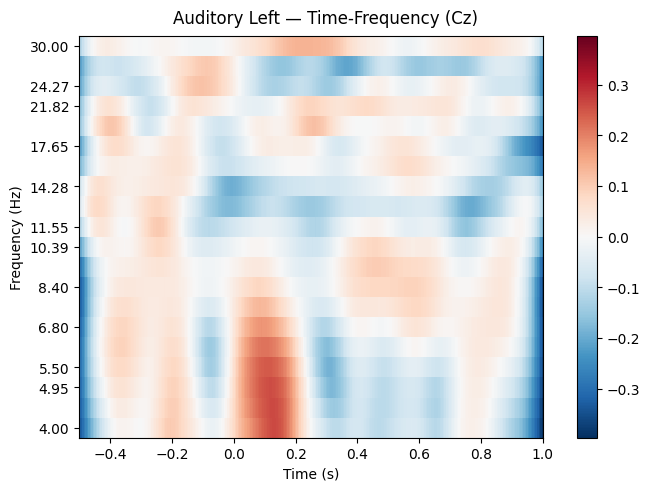

In [80]:
# 对 trials 做平均，选一个通道绘制
power_avg = power.average() # 对 trials 做平均，得到一个 Evoked 对象

# 选 Cz 通道的时频图
fig = power_avg.plot(
    picks=['EEG 030'],          # n_channels选一个通道
    baseline=(-0.5, 0),         # 基线校正
    mode='logratio',            # 对数变化（dB-like）
    title='Auditory Left — Time-Frequency (Cz)',
    colorbar=True,
) # (n_freqs, n_times)

### 5.2 时频地形图：多通道

Applying baseline correction (mode: logratio)


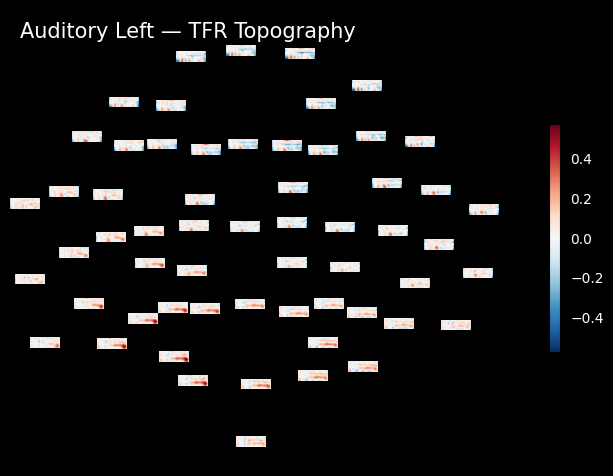

In [ ]:
# 绘制多通道时频地形图 (TFR topomap)
# 在指定时间-频率点上显示电位分布
fig = power_avg.plot_topo(
    baseline=(-0.5, 0),
    mode='logratio',
    title='Auditory Left — TFR Topography',
)

### 5.3 条件间时频对比

对比两个条件的时频差异（常用于 ERD/ERS 分析）。

Applying baseline correction (mode: logratio)


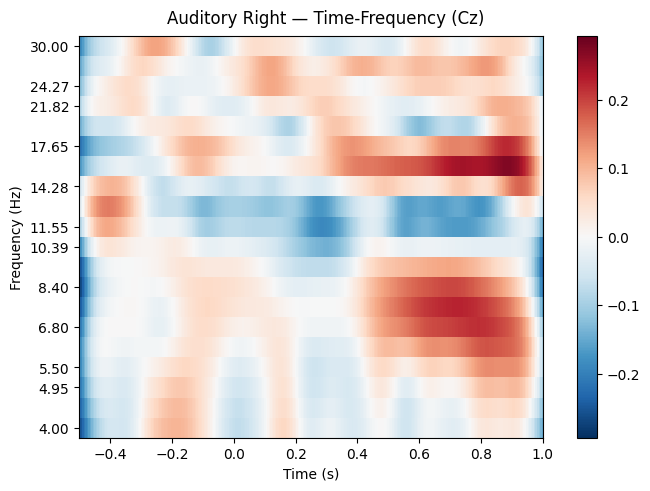

In [77]:
# 计算听觉右侧的时频
power_R = epochs['auditory/right'].compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    use_fft=True,
    return_itc=False,
    decim=3,
    n_jobs=1,
)

# 对 trials 做平均，选一个通道绘制
power_r_avg = power_R.average() # 对 trials 做平均，得到一个 Evoked 对象

# 选 Cz 通道的时频图
fig = power_r_avg.plot(
    picks=['EEG 030'],          # n_channels选一个通道
    baseline=(-0.5, 0),         # 基线校正
    mode='logratio',            # 对数变化（dB-like）
    title='Auditory Right — Time-Frequency (Cz)',
    colorbar=True,
) # (n_freqs, n_times)


Applying baseline correction (mode: percent)


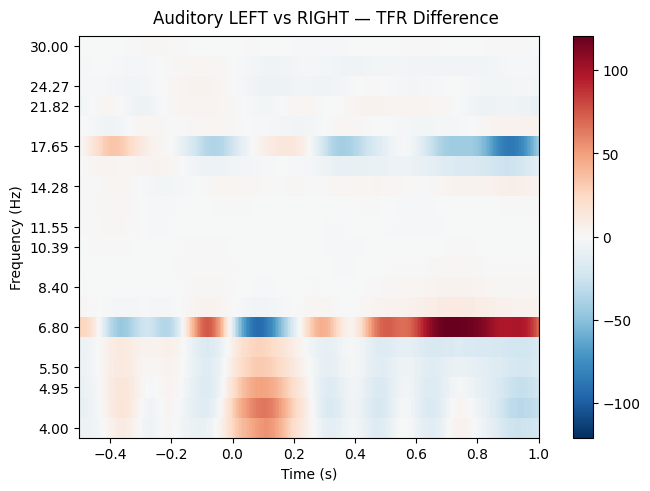

In [78]:

# 差异
power_diff = power.average() - power_R.average()

fig = power_diff.plot(
    picks=['EEG 030'],
    baseline=(-0.5, 0),
    mode='percent',
    title='Auditory LEFT vs RIGHT — TFR Difference',
)

## 6. ERD/ERS 计算

ERD (Event-Related Desynchronization) / ERS (Synchronization)：
- **ERD**：事件后某频段功率相对于基线的降低（去同步化）
- **ERS**：事件后功率的升高（同步化）

MNE 中 ERD/ERS = TFR 结果的 baseline 归一化（logratio 或百分比变化）。

```python
# baseline=(baseline_tmin, baseline_tmax) 用事件前的基线做归一化
power.plot(baseline=(-0.5, 0), mode='percent')  # 百分比变化
power.plot(baseline=(-0.5, 0), mode='logratio') # dB 变化
```

## 7. 可视化最佳实践

| 图类型 | 适用场景 | 函数 |
|--------|---------|------|
| 蝴蝶图 | 快速浏览所有通道 | `evoked.plot(spatial_colors=True)` |
| 单通道 ERP | 经典波形 | `evoked.pick(ch).plot()` |
| 地形图 | 空间分布 | `evoked.plot_topomap(times=...)` |
| Joint Plot | 论文常用 | `evoked.plot_joint(times='peaks')` |
| 条件对比 | 多条件比较 | `plot_compare_evokeds(...)` |
| 时频图 | 频域动态 | `power.plot(picks=ch, baseline=...)` |

## 8. 练习

1. 尝试不同的频率范围（theta 4-8Hz，alpha 8-13Hz，beta 13-30Hz）
2. 用 `mode='percent'` 重做时频图，和 `'logratio'` 对比
3. 在 `plot_compare_evokeds` 中设置 `ci=False` 去掉置信区间